# Destatis GV100AD Store Municipalities Candidate Analysis

This notebook performs a simple candidate-enrichment file review for the Destatis municipality CSV.

Focus areas:
- file presence and basic file properties;
- CSV loading diagnostics;
- row and column overview;
- simple column profiling;
- missing or blank values;
- duplicate rows;
- AGS / Gemeindeschluessel structure checks;
- municipality and administrative fields;
- optional POI/category column detection;
- optional coordinate column detection;
- simple value distributions;
- manual follow-up checklist.

The notebook writes no project data files.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 120)

source_csv = Path(r"C:\Users\simon\food_prediction\raw_data\code_external_data\_external_data\destatis_gv100ad_store_municipalities_2025-12-31\destatis_gv100ad_store_municipalities_2025-12-31.csv")

if not source_csv.exists():
    raise FileNotFoundError(f"Source CSV not found: {source_csv}")

source_csv


WindowsPath('C:/Users/simon/food_prediction/raw_data/code_external_data/_external_data/destatis_gv100ad_store_municipalities_2025-12-31/destatis_gv100ad_store_municipalities_2025-12-31.csv')

## File presence and basic properties


In [2]:
file_stat = source_csv.stat()

file_info = pd.DataFrame([
    {
        "path": str(source_csv),
        "exists": source_csv.exists(),
        "size_bytes": file_stat.st_size,
        "size_mb": round(file_stat.st_size / 1024 / 1024, 3),
        "parent_folder": str(source_csv.parent),
        "file_name": source_csv.name,
    }
])

display(file_info)


,path,exists,size_bytes,size_mb,parent_folder,file_name
0,C:\Users\simon\food_prediction\raw_data\code_external_data\_external_data\destatis_gv100ad_store_municipalities_2025...,True,4768,0.005,C:\Users\simon\food_prediction\raw_data\code_external_data\_external_data\destatis_gv100ad_store_municipalities_2025...,destatis_gv100ad_store_municipalities_2025-12-31.csv


## CSV loading diagnostics


In [3]:
def read_csv_with_simple_attempts(path: Path):
    attempts = []
    candidates = [
        {"sep": ";", "encoding": "utf-8-sig"},
        {"sep": ";", "encoding": "cp1252"},
        {"sep": ",", "encoding": "utf-8-sig"},
        {"sep": ",", "encoding": "cp1252"},
        {"sep": "\t", "encoding": "utf-8-sig"},
        {"sep": "\t", "encoding": "cp1252"},
    ]

    best_frame = None
    best_options = None

    for options in candidates:
        try:
            frame = pd.read_csv(
                path,
                dtype=str,
                keep_default_na=False,
                **options,
            )

            attempts.append(
                {
                    "separator": options["sep"],
                    "encoding": options["encoding"],
                    "success": True,
                    "rows": frame.shape[0],
                    "columns": frame.shape[1],
                    "error": "",
                }
            )

            if best_frame is None or frame.shape[1] > best_frame.shape[1]:
                best_frame = frame
                best_options = options

            if frame.shape[1] > 1:
                return frame, options, pd.DataFrame(attempts)

        except Exception as exc:
            attempts.append(
                {
                    "separator": options["sep"],
                    "encoding": options["encoding"],
                    "success": False,
                    "rows": None,
                    "columns": None,
                    "error": str(exc),
                }
            )

    if best_frame is not None:
        return best_frame, best_options, pd.DataFrame(attempts)

    raise RuntimeError("CSV loading failed for all simple read attempts.")


df, read_options, load_attempts = read_csv_with_simple_attempts(source_csv)

display(load_attempts)
print(f"Selected separator: {repr(read_options['sep'])}")
print(f"Selected encoding: {read_options['encoding']}")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")


,separator,encoding,success,rows,columns,error
0,;,utf-8-sig,True,25,1,
1,;,cp1252,True,25,1,
2,",",utf-8-sig,True,25,21,


Selected separator: ','
Selected encoding: utf-8-sig
Rows: 25
Columns: 21


## Shape and column overview


In [4]:
shape_summary = pd.DataFrame([
    {
        "rows": len(df),
        "columns": df.shape[1],
        "selected_separator": repr(read_options["sep"]),
        "selected_encoding": read_options["encoding"],
    }
])

display(shape_summary)

column_overview_rows = []

for position, column in enumerate(df.columns, start=1):
    series = df[column].astype(str)
    stripped = series.str.strip()
    non_blank = series[stripped != ""]

    example_value = ""
    if not non_blank.empty:
        example_value = non_blank.iloc[0]

    column_overview_rows.append(
        {
            "position": position,
            "column": column,
            "dtype_after_load": str(df[column].dtype),
            "blank_count": int((stripped == "").sum()),
            "blank_percent": round(float((stripped == "").mean() * 100), 2),
            "unique_count": int(series.nunique(dropna=False)),
            "example_non_blank": example_value,
        }
    )

column_overview = pd.DataFrame(column_overview_rows)
display(column_overview)


,rows,columns,selected_separator,selected_encoding
0,25,21,"','",utf-8-sig


,position,column,dtype_after_load,blank_count,blank_percent,unique_count,example_non_blank
0,1,reference_date,str,0,0.0,1,2025-12-31
1,2,municipality_ags,str,0,0.0,25,05334002
2,3,municipality_ars,str,0,0.0,25,053340002002
3,4,state_ars,str,0,0.0,1,05
4,5,regional_district_ars,str,0,0.0,1,3
5,6,district_ars,str,0,0.0,3,34
6,7,association_ars,str,0,0.0,13,0002
7,8,municipality_component,str,0,0.0,13,002
8,9,municipality_name,str,0,0.0,25,"Aachen, Stadt"
9,10,area_km2,str,0,0.0,25,160.85


## Data preview


In [5]:
display(df.head(10))

if len(df) > 10:
    display(df.tail(5))


,reference_date,municipality_ags,municipality_ars,state_ars,regional_district_ars,district_ars,association_ars,municipality_component,municipality_name,area_km2,population_total,population_male,population_female,population_per_km2,administrative_seat_zipcode,centroid_longitude,centroid_latitude,travel_region_code,travel_region_name,urbanisation_code,urbanisation_name
0,2025-12-31,05334002,053340002002,05,3,34,0002,002,"Aachen, Stadt",160.85,262670,137292,125378,1633,52058,"6,0848","50,773516",H01,Eifel und Region Aachen,01,dicht besiedelt
1,2025-12-31,05334004,053340004004,05,3,34,0004,004,"Alsdorf, Stadt",31.68,48810,24259,24551,1541,52477,"6,161607","50,874052",H01,Eifel und Region Aachen,02,mittlere Besiedlungsdichte
2,2025-12-31,05334008,053340008008,05,3,34,0008,008,"Baesweiler, Stadt",27.84,29206,14158,15048,1049,52499,"6,181166","50,906664",H01,Eifel und Region Aachen,02,mittlere Besiedlungsdichte
3,2025-12-31,05334012,053340012012,05,3,34,0012,012,"Eschweiler, Stadt",75.75,57534,28247,29287,760,52249,"6,266781","50,817431",H01,Eifel und Region Aachen,02,mittlere Besiedlungsdichte
4,2025-12-31,05334016,053340016016,05,3,34,0016,016,"Herzogenrath, Stadt",33.38,48574,23832,24742,1455,52134,"6,089184","50,865711",H01,Eifel und Region Aachen,01,dicht besiedelt
5,2025-12-31,05334020,053340020020,05,3,34,0020,020,"Monschau, Stadt",94.6,12389,6130,6259,131,52156,"6,239288","50,555279",H01,Eifel und Region Aachen,03,gering besiedelt
6,2025-12-31,05334024,053340024024,05,3,34,0024,024,"Roetgen, Tor zur Eifel",39.03,8786,4349,4437,225,52159,"6,196427","50,648577",H01,Eifel und Region Aachen,02,mittlere Besiedlungsdichte
7,2025-12-31,05334028,053340028028,05,3,34,0028,028,Simmerath,110.92,16612,8277,8335,150,52152,"6,30057","50,606333",H01,Eifel und Region Aachen,03,gering besiedelt
8,2025-12-31,05334032,053340032032,05,3,34,0032,032,"Stolberg (Rhld.), Kupferstadt",98.48,57684,28530,29154,586,52222,"6,223585","50,776783",H01,Eifel und Region Aachen,02,mittlere Besiedlungsdichte
9,2025-12-31,05334036,053340036036,05,3,34,0036,036,"Würselen, Stadt",34.39,40145,19567,20578,1167,52146,"6,13022","50,821466",H01,Eifel und Region Aachen,02,mittlere Besiedlungsdichte


,reference_date,municipality_ags,municipality_ars,state_ars,regional_district_ars,district_ars,association_ars,municipality_component,municipality_name,area_km2,population_total,population_male,population_female,population_per_km2,administrative_seat_zipcode,centroid_longitude,centroid_latitude,travel_region_code,travel_region_name,urbanisation_code,urbanisation_name
20,2025-12-31,05370012,053700012012,05,3,70,0012,012,"Geilenkirchen, Stadt",83.16,28494,14288,14206,343,52511,"6,119722","50,964538",H02,Niederrhein,02,mittlere Besiedlungsdichte
21,2025-12-31,05370016,053700016016,05,3,70,0016,016,"Heinsberg, Stadt",92.21,43163,21521,21642,468,52525,"6,094538","51,061906",H02,Niederrhein,02,mittlere Besiedlungsdichte
22,2025-12-31,05370020,053700020020,05,3,70,0020,020,"Hückelhoven, Stadt",61.27,41192,20321,20871,672,41836,"6,226269","51,05634",H02,Niederrhein,02,mittlere Besiedlungsdichte
23,2025-12-31,05370028,053700028028,05,3,70,0028,028,"Übach-Palenberg, Stadt",26.09,24277,12133,12144,931,52531,"6,118933","50,919252",H02,Niederrhein,02,mittlere Besiedlungsdichte
24,2025-12-31,05370036,053700036036,05,3,70,0036,036,"Wassenberg, Stadt",42.43,19713,9699,10014,465,41849,"6,155749","51,099533",H02,Niederrhein,02,mittlere Besiedlungsdichte


## Missing and blank values


In [6]:
blank_rows = []

for column in df.columns:
    series = df[column].astype(str)
    blank_mask = series.str.strip() == ""

    blank_rows.append(
        {
            "column": column,
            "blank_count": int(blank_mask.sum()),
            "blank_percent": round(float(blank_mask.mean() * 100), 2),
            "non_blank_count": int((~blank_mask).sum()),
        }
    )

blank_summary = pd.DataFrame(blank_rows).sort_values(
    ["blank_count", "column"],
    ascending=[False, True],
)

display(blank_summary)


,column,blank_count,blank_percent,non_blank_count
14,administrative_seat_zipcode,0,0.0,25
9,area_km2,0,0.0,25
6,association_ars,0,0.0,25
16,centroid_latitude,0,0.0,25
15,centroid_longitude,0,0.0,25
5,district_ars,0,0.0,25
1,municipality_ags,0,0.0,25
2,municipality_ars,0,0.0,25
7,municipality_component,0,0.0,25
8,municipality_name,0,0.0,25


## Duplicate row checks


In [7]:
duplicate_count = int(df.duplicated().sum())

duplicate_summary = pd.DataFrame([
    {
        "exact_duplicate_rows": duplicate_count,
        "row_count": len(df),
        "duplicate_percent": round((duplicate_count / len(df) * 100), 4) if len(df) else 0.0,
    }
])

display(duplicate_summary)

if duplicate_count > 0:
    duplicate_preview = df[df.duplicated(keep=False)].head(20)
    display(duplicate_preview)


,exact_duplicate_rows,row_count,duplicate_percent
0,0,25,0.0


## AGS and Gemeindeschluessel structure checks


In [8]:
key_name_patterns = [
    "ags",
    "gemeindeschluessel",
    "gemeindeschlüssel",
    "schluessel",
    "schlüssel",
    "regional",
    "rs",
]

key_candidates = [
    column
    for column in df.columns
    if any(pattern in column.lower() for pattern in key_name_patterns)
]

display(pd.DataFrame({"candidate_key_columns": key_candidates}))

for column in key_candidates:
    series = df[column].astype(str).str.strip()
    non_blank = series[series != ""]

    print("=" * 80)
    print(f"Column: {column}")
    print(f"Non-blank rows: {len(non_blank):,}")

    if non_blank.empty:
        print("No non-blank values available.")
        continue

    length_counts = (
        non_blank.str.len()
        .value_counts()
        .sort_index()
        .rename_axis("text_length")
        .reset_index(name="row_count")
    )

    digit_only_count = int(non_blank.str.fullmatch(r"\d+").fillna(False).sum())
    leading_zero_count = int(non_blank.str.startswith("0").sum())

    display(pd.DataFrame([
        {
            "column": column,
            "unique_values": int(non_blank.nunique(dropna=False)),
            "digit_only_values": digit_only_count,
            "leading_zero_values": leading_zero_count,
            "min_text_length": int(non_blank.str.len().min()),
            "max_text_length": int(non_blank.str.len().max()),
        }
    ]))

    display(length_counts)
    display(non_blank.drop_duplicates().head(20).to_frame(name="sample_values"))


,candidate_key_columns
0,municipality_ags
1,municipality_ars
2,state_ars
3,regional_district_ars
4,district_ars
5,association_ars


Column: municipality_ags
Non-blank rows: 25


,column,unique_values,digit_only_values,leading_zero_values,min_text_length,max_text_length
0,municipality_ags,25,25,25,8,8


,text_length,row_count
0,8,25


,sample_values
0,05334002
1,05334004
2,05334008
3,05334012
4,05334016
5,05334020
6,05334024
7,05334028
8,05334032
9,05334036


...

,sample_values
0,34
10,58
18,70


Column: association_ars
Non-blank rows: 25


,column,unique_values,digit_only_values,leading_zero_values,min_text_length,max_text_length
0,association_ars,13,25,25,4,4


,text_length,row_count
0,4,25


,sample_values
0,0002
1,0004
2,0008
3,0012
4,0016
5,0020
6,0024
7,0028
8,0032
9,0036


## Municipality and administrative fields


In [9]:
admin_name_patterns = [
    "name",
    "municip",
    "gemeinde",
    "kreis",
    "bezirk",
    "land",
    "state",
    "region",
    "regierungs",
    "verband",
]

admin_candidates = [
    column
    for column in df.columns
    if any(pattern in column.lower() for pattern in admin_name_patterns)
]

display(pd.DataFrame({"candidate_admin_columns": admin_candidates}))

for column in admin_candidates[:12]:
    print("=" * 80)
    print(f"Top values for: {column}")

    top_values = (
        df[column]
        .astype(str)
        .str.strip()
        .replace("", "(blank)")
        .value_counts(dropna=False)
        .head(20)
        .rename_axis(column)
        .reset_index(name="row_count")
    )

    display(top_values)


,candidate_admin_columns
0,municipality_ags
1,municipality_ars
2,state_ars
3,regional_district_ars
4,municipality_component
5,municipality_name
6,travel_region_code
7,travel_region_name
8,urbanisation_name


Top values for: municipality_ags


,municipality_ags,row_count
0,05334002,1
1,05334004,1
2,05334008,1
3,05334012,1
4,05334016,1
5,05334020,1
6,05334024,1
7,05334028,1
8,05334032,1
9,05334036,1


Top values for: municipality_ars


,municipality_ars,row_count
0,053340002002,1
1,053340004004,1
2,053340008008,1
3,053340012012,1
4,053340016016,1
5,053340020020,1
6,053340024024,1
7,053340028028,1
8,053340032032,1
9,053340036036,1


...

,travel_region_code,row_count
0,H01,18
1,H02,7


Top values for: travel_region_name


,travel_region_name,row_count
0,Eifel und Region Aachen,18
1,Niederrhein,7


Top values for: urbanisation_name


,urbanisation_name,row_count
0,mittlere Besiedlungsdichte,16
1,gering besiedelt,6
2,dicht besiedelt,3


## POI and category column detection


In [10]:
category_name_patterns = [
    "poi",
    "category",
    "type",
    "class",
    "amenity",
    "shop",
    "tourism",
    "leisure",
]

category_candidates = [
    column
    for column in df.columns
    if any(pattern in column.lower() for pattern in category_name_patterns)
]

display(pd.DataFrame({"candidate_category_columns": category_candidates}))

if category_candidates:
    for column in category_candidates[:12]:
        print("=" * 80)
        print(f"Top values for: {column}")

        top_values = (
            df[column]
            .astype(str)
            .str.strip()
            .replace("", "(blank)")
            .value_counts(dropna=False)
            .head(25)
            .rename_axis(column)
            .reset_index(name="row_count")
        )

        display(top_values)
else:
    print("No obvious POI or category columns were detected from column names.")


,candidate_category_columns


No obvious POI or category columns were detected from column names.


## Coordinate column detection


In [11]:
coordinate_patterns = [
    r"(^|_)(lat|latitude)($|_)",
    r"(^|_)(lon|lng|longitude)($|_)",
    r"(^|_)(x|y)($|_)",
    r"coord",
    r"east",
    r"north",
]

coordinate_candidates = [
    column
    for column in df.columns
    if any(re.search(pattern, column.lower()) for pattern in coordinate_patterns)
]

display(pd.DataFrame({"candidate_coordinate_columns": coordinate_candidates}))

for column in coordinate_candidates:
    numeric_series = pd.to_numeric(
        df[column].astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce",
    )

    non_blank_count = int((df[column].astype(str).str.strip() != "").sum())
    numeric_count = int(numeric_series.notna().sum())

    display(pd.DataFrame([
        {
            "column": column,
            "non_blank_count": non_blank_count,
            "numeric_count": numeric_count,
            "numeric_percent_of_non_blank": round((numeric_count / non_blank_count * 100), 2) if non_blank_count else 0.0,
            "min_numeric": numeric_series.min(),
            "max_numeric": numeric_series.max(),
        }
    ]))


,candidate_coordinate_columns
0,centroid_longitude
1,centroid_latitude


,column,non_blank_count,numeric_count,numeric_percent_of_non_blank,min_numeric,max_numeric
0,centroid_longitude,25,25,100.0,5.997397,6.484282


,column,non_blank_count,numeric_count,numeric_percent_of_non_blank,min_numeric,max_numeric
0,centroid_latitude,25,25,100.0,50.555279,51.099533


## Simple value distributions


,column,unique_count,blank_count
0,reference_date,1,0
4,regional_district_ars,1,0
3,state_ars,1,0
17,travel_region_code,2,0
18,travel_region_name,2,0
5,district_ars,3,0
19,urbanisation_code,3,0
20,urbanisation_name,3,0
6,association_ars,13,0
7,municipality_component,13,0


Selected low-cardinality columns for charts:
['travel_region_code', 'travel_region_name', 'district_ars', 'urbanisation_code', 'urbanisation_name', 'association_ars', 'municipality_component', 'population_per_km2', 'administrative_seat_zipcode', 'area_km2']


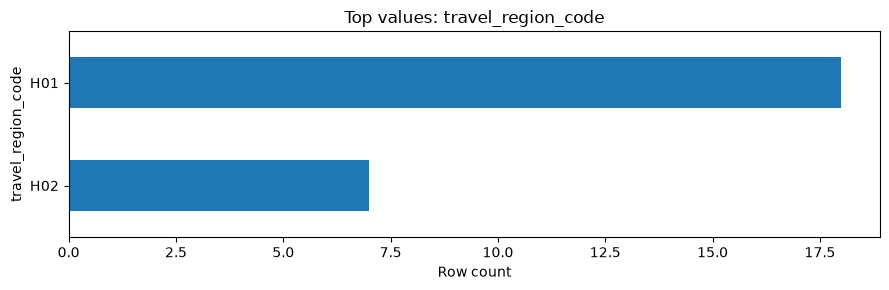

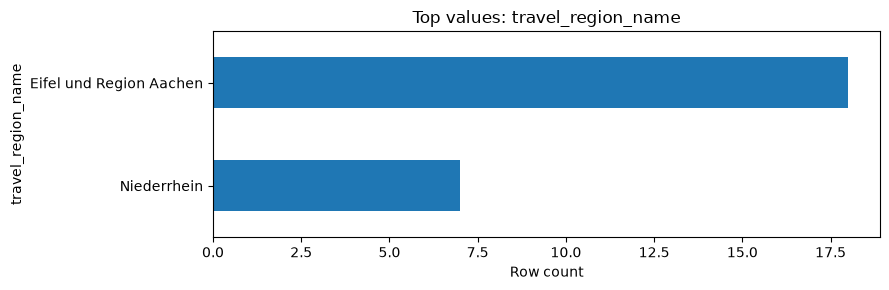

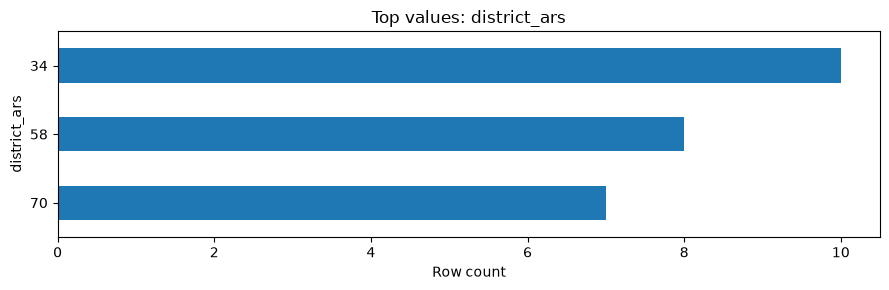

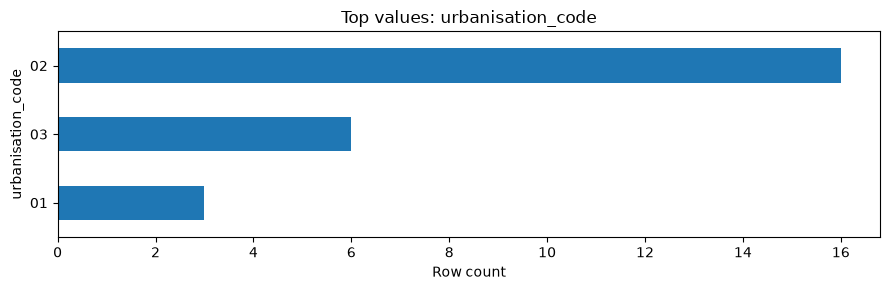

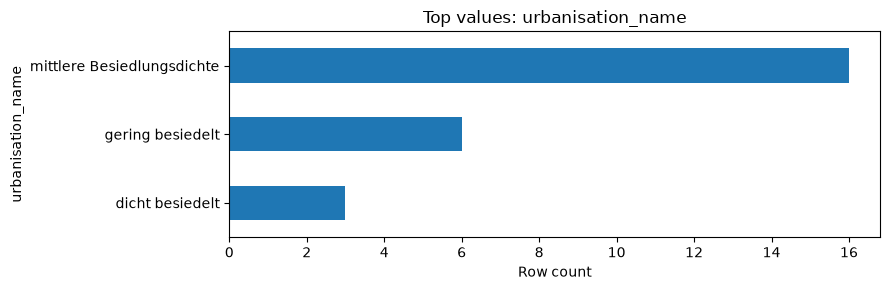

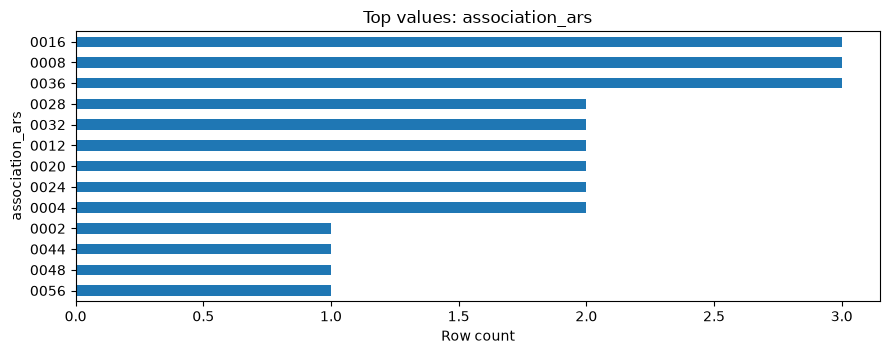

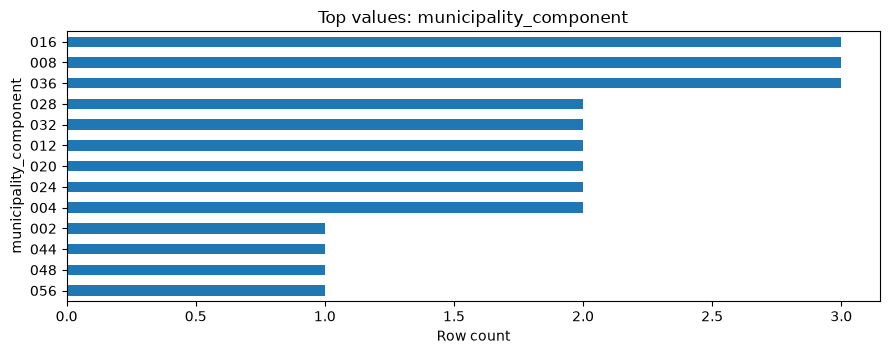

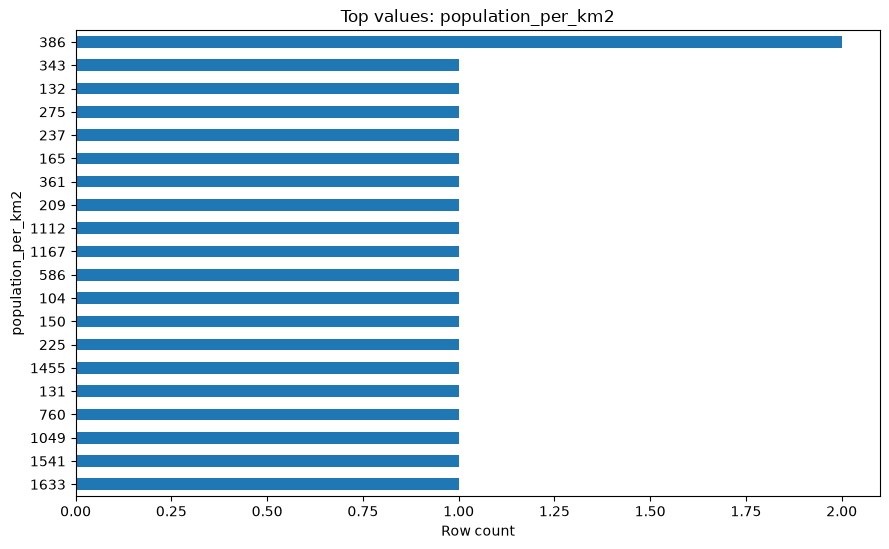

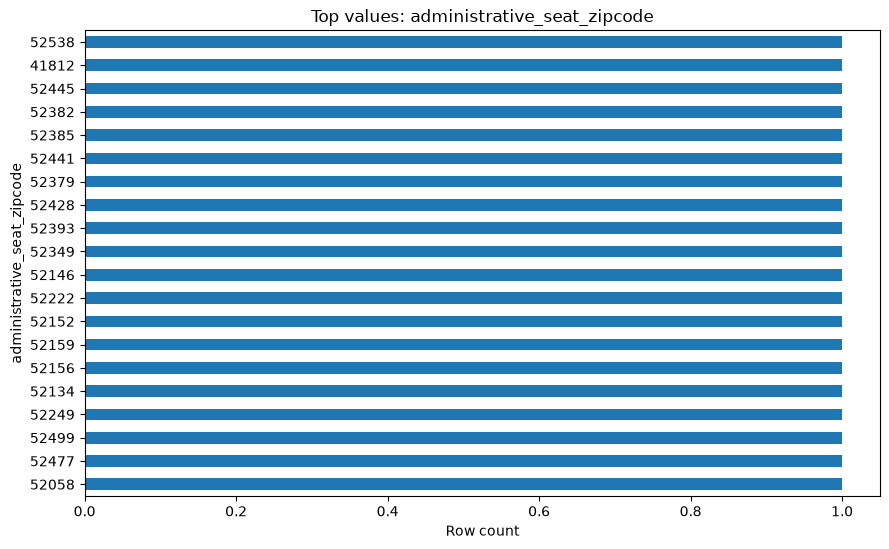

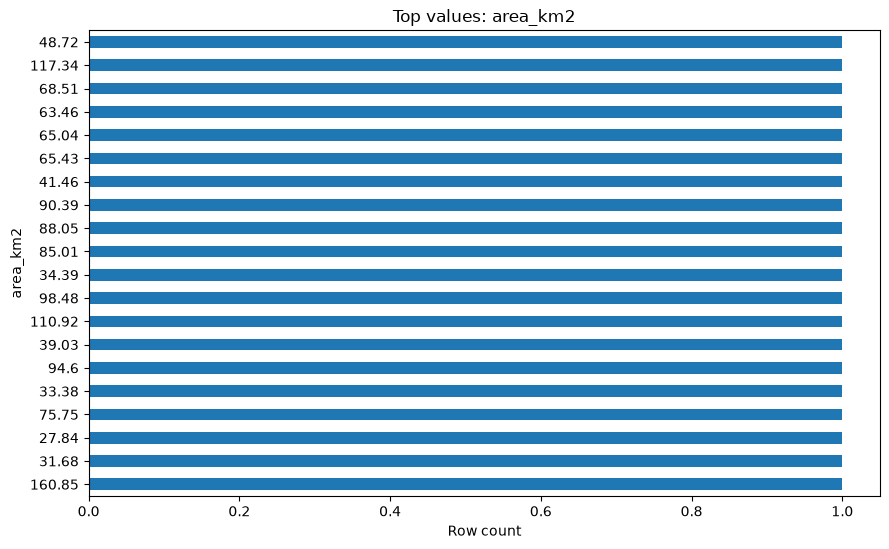

In [12]:
distinct_summary = pd.DataFrame(
    [
        {
            "column": column,
            "unique_count": int(df[column].astype(str).nunique(dropna=False)),
            "blank_count": int((df[column].astype(str).str.strip() == "").sum()),
        }
        for column in df.columns
    ]
).sort_values(["unique_count", "column"])

display(distinct_summary)

low_cardinality_columns = distinct_summary.query("unique_count > 1 and unique_count <= 25")["column"].head(10).tolist()

print("Selected low-cardinality columns for charts:")
print(low_cardinality_columns)

for column in low_cardinality_columns:
    counts = (
        df[column]
        .astype(str)
        .str.strip()
        .replace("", "(blank)")
        .value_counts(dropna=False)
        .head(20)
        .sort_values()
    )

    ax = counts.plot(
        kind="barh",
        figsize=(9, max(3, 0.28 * len(counts))),
    )
    ax.set_title(f"Top values: {column}")
    ax.set_xlabel("Row count")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()


## Simple analysis summary


In [13]:
summary_rows = [
    {
        "check": "Rows loaded",
        "result": len(df),
        "note": "Review expected row count against source documentation.",
    },
    {
        "check": "Columns loaded",
        "result": df.shape[1],
        "note": "Review column names and expected schema.",
    },
    {
        "check": "Exact duplicate rows",
        "result": duplicate_count,
        "note": "Inspect duplicate rows before any later use.",
    },
    {
        "check": "Candidate key columns",
        "result": len(key_candidates),
        "note": "Review AGS / Gemeindeschluessel candidates manually.",
    },
    {
        "check": "Candidate coordinate columns",
        "result": len(coordinate_candidates),
        "note": "Coordinate meaning requires source documentation.",
    },
    {
        "check": "Candidate category columns",
        "result": len(category_candidates),
        "note": "Category semantics require source documentation.",
    },
]

display(pd.DataFrame(summary_rows))


,check,result,note
0,Rows loaded,25,Review expected row count against source documentation.
1,Columns loaded,21,Review column names and expected schema.
2,Exact duplicate rows,0,Inspect duplicate rows before any later use.
3,Candidate key columns,6,Review AGS / Gemeindeschluessel candidates manually.
4,Candidate coordinate columns,2,Coordinate meaning requires source documentation.
5,Candidate category columns,0,Category semantics require source documentation.


## Manual follow-up checklist

- Confirm source identity and stable access method.
- Confirm access or creation date.
- Confirm usage terms.
- Confirm spatial level and temporal reference period.
- Confirm update and revision behavior.
- Confirm AGS / Gemeindeschluessel meaning, format, length, leading zeros, and municipality identity against source documentation.
- Confirm NRW filtering or boundary consistency before any geospatial step.
- Confirm coordinate source and semantics if coordinate-like columns exist.
- Keep this file as candidate enrichment unless a later gated step explicitly changes its role.
